# Market Data Quality — Anomaly Detection

## 1. Objectif du projet

Le notebook construit une pipeline Python de contrôle qualité sur données de marché listées.

La sortie principale est une table d'incidents regroupant les observations à revoir : prix manquants, incohérences OHLC, volumes anormaux, prix figés, rendements extrêmes et profils atypiques détectés par Isolation Forest.

Le sujet est la fiabilisation des données de marché, pas la prédiction de prix ni le trading.


## 2. Logique métier

Une donnée de marché peut être exploitable pour certains usages et problématique pour d'autres. Un prix manquant, un volume nul ou une incohérence entre `high`, `low` et `close` peut affecter un reporting, une mesure de risque, un PnL ou une alimentation référentielle.

La pipeline combine deux niveaux de contrôle :

1. **Règles métier** : contrôles simples, explicites et traçables.
2. **Détection non supervisée** : priorisation d'observations atypiques sur plusieurs variables financières.


## 3. Formules minimales utiles

Rendement logarithmique :

$$
r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)
$$

Volatilité glissante annualisée :

$$
\sigma_{t,n} = \sqrt{252} \times \operatorname{std}(r_{t-n+1}, \ldots, r_t)
$$

Score standardisé :

$$
z_t = \frac{x_t - \mu_x}{\sigma_x}
$$

Score qualité :

$$
Q_t = 1 - \frac{\text{nombre de contrôles en erreur à la date } t}{\text{nombre total de contrôles}}
$$

Isolation Forest isole progressivement les observations dans des arbres aléatoires. Les points isolés rapidement sont considérés comme plus atypiques.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [2]:
def display_kpis(items):
    """Display compact KPI cards in the notebook."""
    cards = ""
    for label, value in items:
        cards += f"""
        <div style="display:inline-block; min-width:150px; margin:6px 8px 6px 0;
                    padding:12px 14px; border:1px solid #d9d9d9; border-radius:6px;
                    background:#fbfbfb; vertical-align:top;">
            <div style="font-size:12px; color:#555; margin-bottom:4px;">{label}</div>
            <div style="font-size:21px; font-weight:600; color:#1f1f1f;">{value}</div>
        </div>
        """
    display(HTML(cards))


def format_count(value):
    return f"{int(value):,}".replace(",", " ")


## 4. Chargement des données

Les données `yfinance` sont optionnelles. Si le téléchargement échoue ou ne renvoie aucune donnée exploitable, le notebook bascule automatiquement vers un dataset synthétique.


In [3]:
TICKERS = ["AAPL", "MSFT", "GLE.PA", "BNP.PA", "ACA.PA", "AIR.PA"]
START_DATE = "2023-01-01"
END_DATE = None


def make_synthetic_market_data(tickers, start="2023-01-01", periods=520):
    """Create OHLCV data with a few controlled anomalies for demonstration."""
    dates = pd.bdate_range(start=start, periods=periods)
    frames = []

    for ticker in tickers:
        base_price = np.random.uniform(40, 180)
        annual_vol = np.random.uniform(0.18, 0.35)
        daily_vol = annual_vol / np.sqrt(252)
        daily_mu = np.random.uniform(0.02, 0.08) / 252

        shocks = np.random.normal(daily_mu, daily_vol, len(dates))
        close = base_price * np.exp(np.cumsum(shocks))
        open_ = close * (1 + np.random.normal(0, 0.003, len(dates)))
        high = np.maximum(open_, close) * (1 + np.abs(np.random.normal(0.003, 0.004, len(dates))))
        low = np.minimum(open_, close) * (1 - np.abs(np.random.normal(0.003, 0.004, len(dates))))
        volume = np.random.lognormal(mean=14, sigma=0.35, size=len(dates)).astype(int)

        frames.append(pd.DataFrame({
            "date": dates,
            "ticker": ticker,
            "open": open_,
            "high": high,
            "low": low,
            "close": close,
            "volume": volume,
            "source": "synthetic_demo",
        }))

    df = pd.concat(frames, ignore_index=True)

    for ticker in tickers[:3]:
        idx = df.index[df["ticker"].eq(ticker)]
        if len(idx) > 330:
            df.loc[idx[80], "close"] *= 1.18
            df.loc[idx[140], "volume"] *= 12
            df.loc[idx[200], "high"] = df.loc[idx[200], "low"] * 0.98
            df.loc[idx[260], "close"] = np.nan
            df.loc[idx[320:323], "close"] = df.loc[idx[319], "close"]

    return df


def load_market_data(tickers, start_date, end_date=None):
    """Load yfinance data when available, otherwise return synthetic data."""
    try:
        import yfinance as yf

        raw = yf.download(
            tickers=tickers,
            start=start_date,
            end=end_date,
            auto_adjust=False,
            progress=False,
            group_by="ticker",
            threads=False,
            timeout=10,
        )

        if raw is None or raw.empty:
            raise ValueError("No data returned by yfinance.")

        frames = []
        for ticker in tickers:
            if isinstance(raw.columns, pd.MultiIndex):
                if ticker not in raw.columns.get_level_values(0):
                    continue
                tmp = raw[ticker].copy()
            else:
                tmp = raw.copy()

            tmp = tmp.reset_index()
            tmp.columns = [str(col).lower().replace(" ", "_") for col in tmp.columns]
            required = ["date", "open", "high", "low", "close", "volume"]

            if not set(required).issubset(tmp.columns):
                continue

            tmp = tmp[required].copy()
            tmp["ticker"] = ticker
            tmp["source"] = "yfinance"
            frames.append(tmp)

        if not frames:
            raise ValueError("No complete OHLCV series returned by yfinance.")

        df = pd.concat(frames, ignore_index=True)
        df["date"] = pd.to_datetime(df["date"])
        df = df[["date", "ticker", "open", "high", "low", "close", "volume", "source"]]
        return df.dropna(how="all", subset=["open", "high", "low", "close"])

    except Exception as exc:
        print(f"Données yfinance indisponibles. Utilisation du dataset synthétique. Détail : {exc}")
        return make_synthetic_market_data(tickers, start=start_date)


market_data = load_market_data(TICKERS, START_DATE, END_DATE)
market_data = market_data.sort_values(["ticker", "date"]).reset_index(drop=True)

display(market_data.head())
display_kpis([
    ("Lignes", format_count(len(market_data))),
    ("Instruments", market_data["ticker"].nunique()),
    ("Source", market_data["source"].mode().iloc[0]),
])


,date,ticker,open,high,low,close,volume,source
0,2023-01-03,AAPL,130.2800,130.9000,124.1700,125.0700,112117500.0000,yfinance
1,2023-01-04,AAPL,126.8900,128.6600,125.0800,126.3600,89113600.0000,yfinance
2,2023-01-05,AAPL,127.1300,127.7700,124.7600,125.0200,80962700.0000,yfinance
3,2023-01-06,AAPL,126.0100,130.2900,124.8900,129.6200,87754700.0000,yfinance
4,2023-01-09,AAPL,130.4700,133.4100,129.8900,130.1500,70790800.0000,yfinance


## 5. Mini-référentiel instruments

Le référentiel apporte le contexte minimal nécessaire pour relier les contrôles à un instrument : classe d'actifs, devise, région de cotation, source attendue et fréquence.


In [4]:
instrument_reference = pd.DataFrame({
    "instrument_id": range(1, len(TICKERS) + 1),
    "ticker": TICKERS,
    "asset_class": ["Equity"] * len(TICKERS),
    "currency": ["USD", "USD", "EUR", "EUR", "EUR", "EUR"],
    "exchange_region": ["US", "US", "Europe", "Europe", "Europe", "Europe"],
    "official_source": ["Yahoo Finance demo"] * len(TICKERS),
    "expected_frequency": ["Daily"] * len(TICKERS),
    "owner_team": ["Market Data"] * len(TICKERS),
})

display(instrument_reference)


,instrument_id,ticker,asset_class,currency,exchange_region,official_source,expected_frequency,owner_team
0,1,AAPL,Equity,USD,US,Yahoo Finance demo,Daily,Market Data
1,2,MSFT,Equity,USD,US,Yahoo Finance demo,Daily,Market Data
2,3,GLE.PA,Equity,EUR,Europe,Yahoo Finance demo,Daily,Market Data
3,4,BNP.PA,Equity,EUR,Europe,Yahoo Finance demo,Daily,Market Data
4,5,ACA.PA,Equity,EUR,Europe,Yahoo Finance demo,Daily,Market Data
5,6,AIR.PA,Equity,EUR,Europe,Yahoo Finance demo,Daily,Market Data


## 6. Contrôles qualité

Les contrôles couvrent les erreurs les plus fréquentes sur un flux OHLCV : prix manquants, prix non positifs, incohérences OHLC, volume manquant ou nul, prix figé et rendement extrême.


In [5]:
def add_quality_flags(df):
    """Add rule-based quality flags to OHLCV observations."""
    df = df.copy().sort_values(["ticker", "date"])
    previous_close = df.groupby("ticker")["close"].shift(1)

    df["log_return"] = np.log(df["close"] / previous_close)
    df["abs_return"] = df["log_return"].abs()

    price_cols = ["open", "high", "low", "close"]
    df["missing_price"] = df[price_cols].isna().any(axis=1).astype(int)
    df["non_positive_price"] = (df[price_cols] <= 0).any(axis=1).astype(int)
    df["high_low_inconsistent"] = (df["high"] < df["low"]).fillna(False).astype(int)
    df["close_outside_range"] = ((df["close"] > df["high"]) | (df["close"] < df["low"])).fillna(False).astype(int)
    df["volume_missing_or_non_positive"] = (df["volume"].isna() | (df["volume"] <= 0)).astype(int)
    df["stale_close_3d"] = (
        df.groupby("ticker")["close"]
        .transform(lambda s: s.eq(s.shift(1)) & s.eq(s.shift(2)) & s.eq(s.shift(3)))
        .fillna(False)
        .astype(int)
    )
    df["extreme_return"] = (df["abs_return"] > 0.08).fillna(False).astype(int)

    quality_flags = [
        "missing_price",
        "non_positive_price",
        "high_low_inconsistent",
        "close_outside_range",
        "volume_missing_or_non_positive",
        "stale_close_3d",
        "extreme_return",
    ]

    df["rule_flag_count"] = df[quality_flags].sum(axis=1)
    df["quality_score"] = 1 - df["rule_flag_count"] / len(quality_flags)
    return df, quality_flags


checked_data, quality_flags = add_quality_flags(market_data)

display(checked_data.head())
display_kpis([
    ("Contrôles", len(quality_flags)),
    ("Lignes avec flag", format_count((checked_data["rule_flag_count"] > 0).sum())),
    ("Taux avec flag", f"{(checked_data['rule_flag_count'] > 0).mean():.2%}"),
])


,date,ticker,open,high,low,close,volume,source,log_return,abs_return,missing_price,non_positive_price,high_low_inconsistent,close_outside_range,volume_missing_or_non_positive,stale_close_3d,extreme_return,rule_flag_count,quality_score
0,2023-01-03,AAPL,130.2800,130.9000,124.1700,125.0700,112117500.0000,yfinance,NaN,NaN,0,0,0,0,0,0,0,0,1.0000
1,2023-01-04,AAPL,126.8900,128.6600,125.0800,126.3600,89113600.0000,yfinance,0.0103,0.0103,0,0,0,0,0,0,0,0,1.0000
2,2023-01-05,AAPL,127.1300,127.7700,124.7600,125.0200,80962700.0000,yfinance,-0.0107,0.0107,0,0,0,0,0,0,0,0,1.0000
3,2023-01-06,AAPL,126.0100,130.2900,124.8900,129.6200,87754700.0000,yfinance,0.0361,0.0361,0,0,0,0,0,0,0,0,1.0000
4,2023-01-09,AAPL,130.4700,133.4100,129.8900,130.1500,70790800.0000,yfinance,0.0041,0.0041,0,0,0,0,0,0,0,0,1.0000


,count
extreme_return,16
non_positive_price,0
missing_price,0
high_low_inconsistent,0
close_outside_range,0
volume_missing_or_non_positive,0
stale_close_3d,0


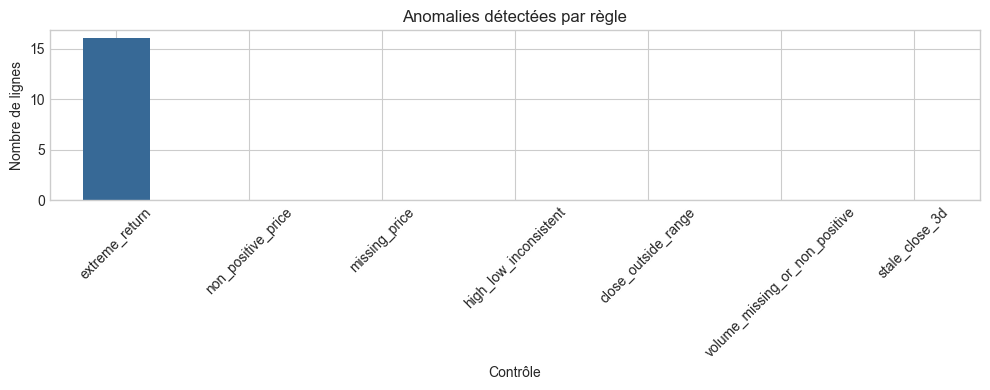

In [6]:
quality_summary = (
    checked_data[quality_flags]
    .sum()
    .sort_values(ascending=False)
    .rename("count")
    .to_frame()
)

display(quality_summary)

fig, ax = plt.subplots(figsize=(10, 4))
quality_summary["count"].plot(kind="bar", ax=ax, color="#376996")
ax.set_title("Anomalies détectées par règle")
ax.set_xlabel("Contrôle")
ax.set_ylabel("Nombre de lignes")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


## 7. Features financières simples

Les variables utilisées par le modèle restent interprétables : rendement, amplitude absolue, volatilité glissante, amplitude intraday, gap d'ouverture, volume standardisé et score qualité.


In [7]:
def add_financial_features(df):
    """Create simple financial features for anomaly detection."""
    df = df.copy().sort_values(["ticker", "date"])
    g = df.groupby("ticker", group_keys=False)

    df["rolling_vol_5d"] = g["log_return"].transform(lambda s: s.rolling(5, min_periods=3).std() * np.sqrt(252))
    df["rolling_vol_20d"] = g["log_return"].transform(lambda s: s.rolling(20, min_periods=10).std() * np.sqrt(252))
    df["price_range_pct"] = (df["high"] - df["low"]) / df["close"]
    df["open_close_gap"] = (df["open"] - g["close"].shift(1)) / g["close"].shift(1)
    df["volume_log"] = np.log1p(df["volume"])
    df["volume_zscore_60d"] = g["volume_log"].transform(
        lambda s: (s - s.rolling(60, min_periods=20).mean()) / s.rolling(60, min_periods=20).std()
    )

    feature_cols = [
        "log_return",
        "abs_return",
        "rolling_vol_5d",
        "rolling_vol_20d",
        "price_range_pct",
        "open_close_gap",
        "volume_zscore_60d",
        "quality_score",
    ]
    return df, feature_cols


feature_data, feature_cols = add_financial_features(checked_data)
display(feature_data[["date", "ticker"] + feature_cols].head(10))


,date,ticker,log_return,abs_return,rolling_vol_5d,rolling_vol_20d,price_range_pct,open_close_gap,volume_zscore_60d,quality_score
0,2023-01-03,AAPL,NaN,NaN,NaN,NaN,0.0538,NaN,NaN,1.0000
1,2023-01-04,AAPL,0.0103,0.0103,NaN,NaN,0.0283,0.0146,NaN,1.0000
2,2023-01-05,AAPL,-0.0107,0.0107,NaN,NaN,0.0241,0.0061,NaN,1.0000
3,2023-01-06,AAPL,0.0361,0.0361,0.3721,NaN,0.0417,0.0079,NaN,1.0000
4,2023-01-09,AAPL,0.0041,0.0041,0.3101,NaN,0.0270,0.0066,NaN,1.0000
5,2023-01-10,AAPL,0.0044,0.0044,0.2714,NaN,0.0240,0.0008,NaN,1.0000
6,2023-01-11,AAPL,0.0209,0.0209,0.2850,NaN,0.0228,0.0040,NaN,1.0000
7,2023-01-12,AAPL,-0.0006,0.0006,0.2427,NaN,0.0211,0.0029,NaN,1.0000
8,2023-01-13,AAPL,0.0101,0.0101,0.1309,NaN,0.0242,-0.0103,NaN,1.0000
9,2023-01-17,AAPL,0.0087,0.0087,0.1268,NaN,0.0232,0.0005,NaN,1.0000


## 8. Détection d'anomalies avec Isolation Forest

Isolation Forest sert à prioriser les observations atypiques sur plusieurs dimensions. Le modèle ne remplace pas les règles métier ; il complète la revue en remontant des combinaisons inhabituelles de prix, volatilité, volume et score qualité.


In [8]:
def fit_isolation_forest(df, feature_cols, contamination=0.02):
    """Fit Isolation Forest and append anomaly indicators to the dataset."""
    df = df.copy()
    model_data = df.replace([np.inf, -np.inf], np.nan).dropna(subset=feature_cols).copy()

    X = model_data[feature_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=RANDOM_STATE,
    )

    predictions = model.fit_predict(X_scaled)
    decision_score = model.decision_function(X_scaled)

    model_data["ml_anomaly"] = (predictions == -1).astype(int)
    model_data["anomaly_score"] = -decision_score

    df["ml_anomaly"] = 0
    df["anomaly_score"] = np.nan
    df.loc[model_data.index, "ml_anomaly"] = model_data["ml_anomaly"]
    df.loc[model_data.index, "anomaly_score"] = model_data["anomaly_score"]

    return df, model, scaler


scored_data, model, scaler = fit_isolation_forest(feature_data, feature_cols, contamination=0.02)

display_kpis([
    ("Anomalies modèle", format_count(scored_data["ml_anomaly"].sum())),
    ("Score moyen", f"{scored_data['anomaly_score'].mean():.4f}"),
    ("Score max", f"{scored_data['anomaly_score'].max():.4f}"),
])


In [9]:
top_anomalies = (
    scored_data
    .sort_values("anomaly_score", ascending=False)
    .loc[:, [
        "date", "ticker", "close", "volume", "log_return", "rolling_vol_20d",
        "volume_zscore_60d", "rule_flag_count", "quality_score", "ml_anomaly", "anomaly_score",
    ]]
    .head(15)
)

styled_top_anomalies = (
    top_anomalies.style
    .format({
        "close": "{:,.2f}",
        "volume": "{:,.0f}",
        "log_return": "{:.2%}",
        "rolling_vol_20d": "{:.2%}",
        "volume_zscore_60d": "{:.2f}",
        "quality_score": "{:.2f}",
        "anomaly_score": "{:.4f}",
    })
    .background_gradient(subset=["anomaly_score"], cmap="YlOrRd")
)

display(styled_top_anomalies)


,date,ticker,close,volume,log_return,rolling_vol_20d,volume_zscore_60d,rule_flag_count,quality_score,ml_anomaly,anomaly_score
568,2025-04-09 00:00:00,AAPL,198.85,"184,395,900",14.26%,75.38%,3.01,1,0.86,1,0.1855
3596,2023-09-18 00:00:00,GLE.PA,23.28,"22,477,716",-12.84%,48.23%,4.57,1,0.86,1,0.1853
3466,2023-03-15 00:00:00,GLE.PA,21.50,"18,101,400",-12.98%,59.21%,3.41,1,0.86,1,0.1782
3950,2025-02-06 00:00:00,GLE.PA,34.96,"13,136,386",12.38%,46.16%,3.51,1,0.86,1,0.1732
2609,2023-03-15 00:00:00,BNP.PA,52.03,"13,047,147",-10.66%,53.48%,3.56,1,0.86,1,0.1707
3991,2025-04-04 00:00:00,GLE.PA,34.54,"13,263,669",-11.03%,52.04%,3.26,1,0.86,1,0.1620
5041,2026-01-29 00:00:00,MSFT,433.50,"128,855,300",-10.53%,44.22%,3.88,1,0.86,1,0.1616
3883,2024-10-31 00:00:00,GLE.PA,26.39,"15,267,248",10.73%,38.82%,4.06,1,0.86,1,0.1555
2077,2024-06-25 00:00:00,AIR.PA,134.78,"8,026,551",-9.88%,38.92%,4.92,1,0.86,1,0.1486
4246,2026-04-08 00:00:00,GLE.PA,70.61,"4,883,128",8.88%,59.54%,1.88,1,0.86,1,0.1429


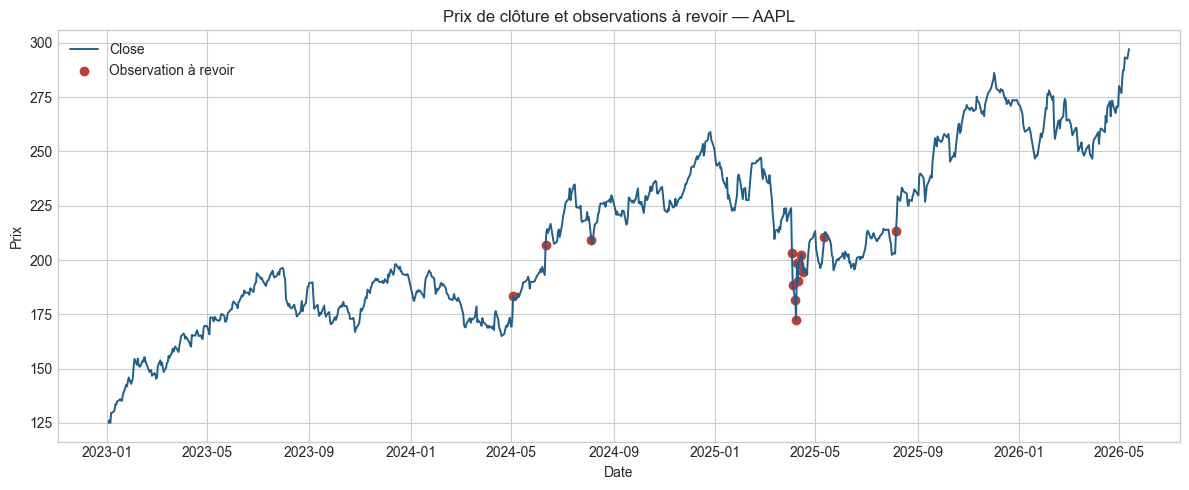

In [10]:
ticker_to_plot = scored_data["ticker"].iloc[0]
plot_df = scored_data[scored_data["ticker"].eq(ticker_to_plot)].copy()
plot_anomalies = plot_df[(plot_df["ml_anomaly"] == 1) | (plot_df["rule_flag_count"] > 0)]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(plot_df["date"], plot_df["close"], linewidth=1.4, label="Close", color="#1f5f8b")
ax.scatter(plot_anomalies["date"], plot_anomalies["close"], s=36, color="#c43b31", label="Observation à revoir")
ax.set_title(f"Prix de clôture et observations à revoir — {ticker_to_plot}")
ax.set_xlabel("Date")
ax.set_ylabel("Prix")
ax.legend()
plt.tight_layout()
plt.show()


## 9. Table d'incidents

La table d'incidents concentre les observations à revoir. Elle indique l'instrument, la date, les règles déclenchées, la sévérité, une cause possible et une action recommandée.


In [11]:
def build_incident_table(df, quality_flags):
    """Build an operational incident table from rule flags and model anomalies."""
    df = df.copy()

    def collect_flags(row):
        active_flags = [flag for flag in quality_flags if row.get(flag, 0) == 1]
        return ", ".join(active_flags) if active_flags else ""

    def severity(row):
        if row["rule_flag_count"] >= 2:
            return "High"
        if row["missing_price"] == 1 or row["high_low_inconsistent"] == 1:
            return "High"
        if row["ml_anomaly"] == 1 and row["rule_flag_count"] >= 1:
            return "High"
        if row["ml_anomaly"] == 1 or row["rule_flag_count"] == 1:
            return "Medium"
        return "Low"

    def possible_cause(row):
        if row["missing_price"] == 1:
            return "Missing market data"
        if row["high_low_inconsistent"] == 1 or row["close_outside_range"] == 1:
            return "OHLC inconsistency"
        if row["volume_missing_or_non_positive"] == 1:
            return "Volume issue"
        if row["stale_close_3d"] == 1:
            return "Potential stale price"
        if row["extreme_return"] == 1:
            return "Extreme price move"
        if row["ml_anomaly"] == 1:
            return "Unusual multivariate pattern"
        return "No incident"

    incidents = df[(df["rule_flag_count"] > 0) | (df["ml_anomaly"] == 1)].copy()
    incidents["rule_flags"] = incidents.apply(collect_flags, axis=1)
    incidents["detected_by"] = np.select(
        [
            (incidents["rule_flag_count"] > 0) & (incidents["ml_anomaly"] == 1),
            incidents["rule_flag_count"] > 0,
            incidents["ml_anomaly"] == 1,
        ],
        ["Rules + model", "Rules", "Model"],
        default="None",
    )
    incidents["severity"] = incidents.apply(severity, axis=1)
    incidents["possible_cause"] = incidents.apply(possible_cause, axis=1)
    incidents["recommended_action"] = np.select(
        [incidents["severity"].eq("High"), incidents["severity"].eq("Medium")],
        ["Manual review and source validation", "Monitor and compare with official source"],
        default="No action",
    )

    severity_order = pd.CategoricalDtype(["High", "Medium", "Low"], ordered=True)
    incidents["severity"] = incidents["severity"].astype(severity_order)
    incidents = incidents.sort_values(["severity", "date", "ticker"], ascending=[True, False, True])
    incidents.insert(0, "incident_id", range(1, len(incidents) + 1))

    final_cols = [
        "incident_id", "date", "ticker", "source", "close", "volume", "rule_flags",
        "detected_by", "severity", "possible_cause", "recommended_action",
        "anomaly_score", "quality_score",
    ]
    return incidents[final_cols]


incident_table = build_incident_table(scored_data, quality_flags)

display(incident_table.head(20))
display_kpis([
    ("Incidents", format_count(len(incident_table))),
    ("High", format_count(incident_table["severity"].eq("High").sum())),
    ("Medium", format_count(incident_table["severity"].eq("Medium").sum())),
])


,incident_id,date,ticker,source,close,volume,rule_flags,detected_by,severity,possible_cause,recommended_action,anomaly_score,quality_score
4246,1,2026-04-08,GLE.PA,yfinance,70.6100,4883128.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1429,0.8571
5041,2,2026-01-29,MSFT,yfinance,433.5000,128855300.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1616,0.8571
3272,3,2025-10-20,BNP.PA,yfinance,69.1000,13072979.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1362,0.8571
568,4,2025-04-09,AAPL,yfinance,198.8500,184395900.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1855,0.8571
4839,5,2025-04-09,MSFT,yfinance,390.4900,50199700.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1387,0.8571
3991,6,2025-04-04,GLE.PA,yfinance,34.5450,13263669.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1620,0.8571
564,7,2025-04-03,AAPL,yfinance,203.1900,103419000.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1241,0.8571
3950,8,2025-02-06,GLE.PA,yfinance,34.9550,13136386.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1732,0.8571
3883,9,2024-10-31,GLE.PA,yfinance,26.3850,15267248.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1555,0.8571
3818,10,2024-08-01,GLE.PA,yfinance,21.8300,15387364.0000,extreme_return,Rules + model,High,Extreme price move,Manual review and source validation,0.1197,0.8571


## 10. Exports

Les fichiers exportés sont écrits dans `outputs/` pour séparer les résultats générés du code source.


In [12]:
scored_path = OUTPUT_DIR / "market_data_scored.csv"
incidents_path = OUTPUT_DIR / "market_data_incidents.csv"
reference_path = OUTPUT_DIR / "instrument_reference.csv"

scored_data.to_csv(scored_path, index=False)
incident_table.to_csv(incidents_path, index=False)
instrument_reference.to_csv(reference_path, index=False)

print("Exports créés :")
print(f"- {scored_path.as_posix()}")
print(f"- {incidents_path.as_posix()}")
print(f"- {reference_path.as_posix()}")


Exports créés :
- outputs/market_data_scored.csv
- outputs/market_data_incidents.csv
- outputs/instrument_reference.csv


## 11. Limites et améliorations possibles

- `yfinance` est utilisé comme source de démonstration.
- Les seuils doivent être calibrés par classe d'actifs, liquidité, devise et source.
- Le notebook n'utilise pas de labels d'incidents réels.
- En production, les contrôles devraient être historisés et suivis dans le temps.
- Le suivi des faux positifs permettrait d'ajuster les règles et le seuil de contamination du modèle.
